In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn

# Import Data

In [4]:
# Read in the data
df = pd.read_csv("data_with_targets.csv")

# Keep only labels (1,2) and remap to (0,1)
data = df[df.iloc[:, -1].isin([1, 2])].copy()
data.iloc[:, -1] -= 1

X = data.iloc[:, 1:-1].to_numpy()   # Remove 1st and last column
y = data.iloc[:, -1].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

# Only two features

In [6]:
X = data.iloc[:, 3:-1].to_numpy()   
y = data.iloc[:, -1].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

2

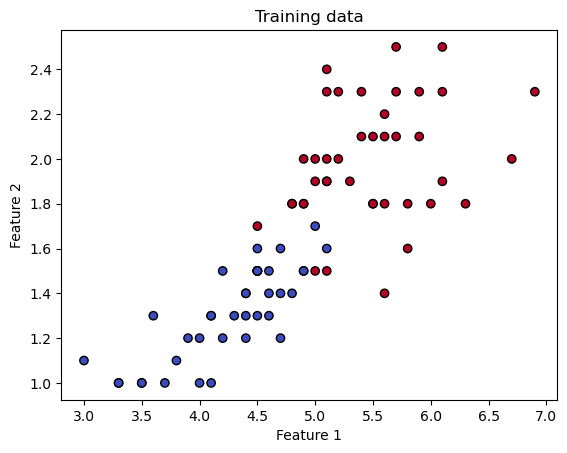

In [5]:
plt.scatter(X_train[:, 0].numpy(), X_train[:, 1].numpy(),
    c=y_train.numpy().ravel(), cmap="coolwarm", edgecolors="k")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training data")
plt.show()

# Neural Network

In [6]:
class SimpleNetwork(nn.Module):
    def __init__(self, d_in = X_train.shape[1]):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 16),
            nn.Sigmoid(),
            nn.Linear(16, 8),
            nn.Sigmoid(),
            nn.Linear(8, 1),
            nn.Sigmoid()        # <-- explicit output sigmoid
        )

    def forward(self, x):
        return self.net(x)


In [7]:
torch.manual_seed(0)

model = SimpleNetwork(d_in=X_train.shape[1])

# Train Model

In [8]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

In [9]:
epoch = 200
losses = []
for i in range(epoch):
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())

    # print every 10 epochs
    if i % 10 == 0:
        print(f'Epoch: {i} and loss: {loss}')

Epoch: 0 and loss: 0.6926319003105164
Epoch: 10 and loss: 0.6829918026924133
Epoch: 20 and loss: 0.6634515523910522
Epoch: 30 and loss: 0.6229044795036316
Epoch: 40 and loss: 0.555123507976532
Epoch: 50 and loss: 0.46102532744407654
Epoch: 60 and loss: 0.36559951305389404
Epoch: 70 and loss: 0.29276639223098755
Epoch: 80 and loss: 0.24562039971351624
Epoch: 90 and loss: 0.21448281407356262
Epoch: 100 and loss: 0.1920301616191864
Epoch: 110 and loss: 0.17526963353157043
Epoch: 120 and loss: 0.16256511211395264
Epoch: 130 and loss: 0.15312309563159943
Epoch: 140 and loss: 0.1460428386926651
Epoch: 150 and loss: 0.14081645011901855
Epoch: 160 and loss: 0.13698625564575195
Epoch: 170 and loss: 0.1342192143201828
Epoch: 180 and loss: 0.13219818472862244
Epoch: 190 and loss: 0.13067373633384705


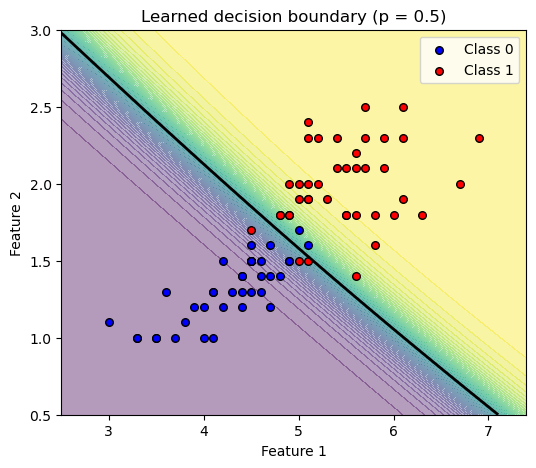

In [16]:
X_test_np = np.asarray(X_test)
y_test_np = np.asarray(y_test).reshape(-1)   # <- KEY FIX (N,1) -> (N,)

X_train_np = np.asarray(X_train)
y_train_np = np.asarray(y_train).reshape(-1)

x_min, x_max = X_train_np[:, 0].min() - 0.5, X_train_np[:, 0].max() + 0.5
y_min, y_max = X_train_np[:, 1].min() - 0.5, X_train_np[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))

grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
grid_t = torch.tensor(grid, dtype=torch.float32)

# --- Model predictions on grid ---
model.eval()
with torch.no_grad():
    probs = model(grid_t).numpy().reshape(xx.shape)

plt.figure(figsize=(6, 5))

# Background + decision boundary
plt.contourf(xx, yy, probs, levels=50, alpha=0.4)
plt.contour(xx, yy, probs, levels=[0.5], linewidths=2, colors="black")

# Plot class 0
plt.scatter(X_train_np[y_train_np == 0, 0], X_train_np[y_train_np == 0, 1], color="blue", edgecolors="k", s=30, label="Class 0")

# Plot class 1
plt.scatter(X_train_np[y_train_np == 1, 0], X_train_np[y_train_np == 1, 1], color="red", edgecolors="k", s=30, label="Class 1")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Learned decision boundary (p = 0.5)")
plt.legend()
plt.show()
